In [1]:
import pandas as pd
import numpy as np
import io

In [3]:
# =========================================================
# STEP 1: LOAD & PREPARE THE GRID DATA
# =========================================================
print("Loading Taipower grid logs...")
df_taipower = pd.read_csv('data/taipower_data.csv')

# Ensure timestamps are actual Datetime objects
df_taipower['Time_Occurred'] = pd.to_datetime(df_taipower['Time_Occurred'], errors='coerce')

# Filter for infrastructure/weather failure keywords
weather_keywords = [
    '饋線事故停電', '饋線全停', '分歧開關跳脫', '欠相', '斷線', 
    '過流電驛動作', '差動電驛動作', '51動作', '51N動作', '斷路器跳脫', '越級跳脫'
]
pattern = '|'.join(weather_keywords)
df_grid_faults = df_taipower[df_taipower['Incident_Description'].str.contains(pattern, na=False)].copy()

print(f"Filtered down to {len(df_grid_faults)} relevant weather-related grid faults.")
df_grid_faults

Loading Taipower grid logs...
Filtered down to 25 relevant weather-related grid faults.


,Incident_ID,Time_Occurred,Incident_Description,Households_Affected,Time_Restored
0,1,2024-12-25 23:27:00,榮成變電所第59條饋線全停逾時一小時以上事故,1,2024-12-26 02:07:00
4,5,2024-12-10 11:30:00,西螺服務區南下休息站欠相停電事故,10,2024-12-10 16:00:00
14,15,2024-11-02 10:22:00,中部科學園區編號H467饋線事故停電,112,2024-11-02 10:22:00
27,28,2024-10-01 19:30:00,中部科學園區編號H875饋線事故停電(聯亞科技),1,2024-10-01 19:40:00
28,29,2024-09-28 18:15:00,興變電所9I28饋線相間過流電驛動作造成饋線斷路器跳脫，事故停電,"3,230",2024-09-28 18:42:00
35,36,2024-09-19 01:01:00,中正變電所第51號饋線事故停電,"3,093",2024-09-19 02:20:00
37,38,2024-09-16 17:55:00,成都變電所第62號饋線事故停電,"1,915",2024-09-16 18:39:00
44,45,2024-09-01 05:12:00,新豐配電變電所第59饋線事故停電,1,2024-09-01 05:16:00
51,52,2024-07-31 02:40:00,內惟配電變電所第74饋線斷路器跳脫事故停電,253,2024-07-31 03:29:00
55,56,2024-07-16 14:04:00,成都變電所第62饋線事故停電,"2,350",2024-07-16 14:09:00


In [ ]:
df.

In [5]:
# =========================================================
# STEP 2: LOAD STORM DATA & GEOMAP
# =========================================================
print("Loading JMA storm tracks...")
df_storm = pd.read_csv('data/typhoon_data_final.csv')

# Ensure we use Taiwan Local Time (JMA is in UTC, so we add 8 hours)
df_storm['Timestamp'] = pd.to_datetime(df_storm['Timestamp'], errors='coerce') + pd.Timedelta(hours=8)
df_storm_2024 = df_storm[df_storm['Timestamp'].dt.year >= 2024].copy()

# Substation Infrastructure Locations
geomap_csv = """name,latitude,longitude
榮成變電所,25.05482,121.13183
西螺服務區,23.7987,120.4665
中部科學園區,24.2173,120.6997
興變電所,23.5,120.8
中正變電所,25.0329,121.5654
成都變電所,24.9936,121.3010
新豐配電變電所,24.9053,120.9839
內惟配電變電所,22.6663,120.2862
永華二次變電所,22.9908,120.2133
關西二次變電所,24.7920,121.1760
源海二次變電所,25.0330,121.5654
四湖配電變電所,23.6367,120.2250
新高港超高壓變電所,22.570017,120.407833
九曲配電變電所,22.9900,120.2000
崙背變電所,23.7580,120.3530
常德變電所,25.0600,121.5200
嶺口二次變電所,22.7580,120.3600
龍明配電變電所,24.9930,121.2960
新工配電變電所,24.8138,120.9675"""

df_geo = pd.read_csv(io.StringIO(geomap_csv))
df_geo

Loading JMA storm tracks...


,name,latitude,longitude
0,榮成變電所,25.054820,121.131830
1,西螺服務區,23.798700,120.466500
2,中部科學園區,24.217300,120.699700
3,興變電所,23.500000,120.800000
4,中正變電所,25.032900,121.565400
5,成都變電所,24.993600,121.301000
6,新豐配電變電所,24.905300,120.983900
7,內惟配電變電所,22.666300,120.286200
8,永華二次變電所,22.990800,120.213300
9,關西二次變電所,24.792000,121.176000


In [6]:
# =========================================================
# STEP 3: CARTESIAN ALIGNMENT & PHYSICS ENGINE
# =========================================================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0 # Earth radius in km
    dLat, dLon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dLat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dLon/2)**2
    return R * (2 * np.arctan2(np.sqrt(a), np.sqrt(1-a)))

# Match every Storm Track with every Grid Node (Cartesian Product)
df_storm_2024['key'], df_geo['key'] = 1, 1
df_cross = pd.merge(df_storm_2024, df_geo, on='key').drop('key', axis=1)

# Calculate Spatial Distance
df_cross['Distance_to_Node_km'] = haversine(
    df_cross['latitude'], df_cross['longitude'], 
    df_cross['Latitude'], df_cross['Longitude'] 
)

# Wide radius (1500km) to capture early storm staging and massive outer bands
df_danger = df_cross[df_cross['Distance_to_Node_km'] <= 1500.0].copy()

# Extend the window to 24 hours to catch delayed/pre-emptive faults
TIME_WINDOW = pd.Timedelta(hours=24)

def verify_node_failure(node_name, storm_time, grid_df, window):
    # Did the incident description mention THIS node, at THIS time?
    mask = (
        (grid_df['Time_Occurred'] >= storm_time - window) & 
        (grid_df['Time_Occurred'] <= storm_time + window) & 
        (grid_df['Incident_Description'].str.contains(node_name, na=False))
    )
    return 1 if mask.any() else 0

print(f"\nEvaluating {len(df_danger)} localized danger zone events...")

# Execute the temporal alignment
df_danger['Target_Failure'] = df_danger.apply(
    lambda row: verify_node_failure(row['name'], row['Timestamp'], df_grid_faults, TIME_WINDOW), 
    axis=1
)


Evaluating 15555 localized danger zone events...


In [7]:
# =========================================================
# STEP 4: FINALIZE QUANTUM DATASET (FEATURE UPGRADE)
# =========================================================
# Swapped 'Wind_Knots' for 'Grade' to prevent zero-value confusion on weak depressions
qkn_features = ['Timestamp', 'name', 'Storm_Name', 'Grade', 'Pressure', 'Distance_to_Node_km', 'Target_Failure']
df_qkn_final = df_danger[qkn_features].rename(columns={'name': 'Node_Name'})

print("\n=== PHASE 1 TO 4 COMPLETE ===")
print("Balanced Target Class Distribution:")
print(df_qkn_final['Target_Failure'].value_counts())
print("\nSample Data Ready for QKN:")
print(df_qkn_final.head())


=== PHASE 1 TO 4 COMPLETE ===
Balanced Target Class Distribution:
Target_Failure
0    15499
1       56
Name: count, dtype: int64

Sample Data Ready for QKN:
             Timestamp Node_Name Storm_Name  Grade  Pressure  \
77 2024-05-25 02:00:00     西螺服務區    EWINIAR      2    1004.0   
79 2024-05-25 02:00:00      興變電所    EWINIAR      2    1004.0   
83 2024-05-25 02:00:00   內惟配電變電所    EWINIAR      2    1004.0   
84 2024-05-25 02:00:00   永華二次變電所    EWINIAR      2    1004.0   
87 2024-05-25 02:00:00   四湖配電變電所    EWINIAR      2    1004.0   

    Distance_to_Node_km  Target_Failure  
77          1480.794552               0  
79          1437.763521               0  
83          1371.301527               0  
84          1407.368499               0  
87          1473.112499               0  


In [9]:
set(df_qkn_final['Target_Failure'])

{0, 1}

In [10]:
df_qkn_final['Target_Failure'].value_counts()

Target_Failure
0    15499
1       56
Name: count, dtype: int64

In [11]:
# Convert Time_Restored to datetime objects (if not already done)
df_taipower['Time_Restored'] = pd.to_datetime(df_taipower['Time_Restored'], errors='coerce')

# Calculate the exact difference between restoration and occurrence
df_taipower['Outage_Duration'] = df_taipower['Time_Restored'] - df_taipower['Time_Occurred']

# Create a clean float column representing the total hours the grid was down
df_taipower['Outage_Duration_Hours'] = df_taipower['Outage_Duration'].dt.total_seconds() / 3600

In [14]:
df_taipower['Outage_Duration_Hours'].describe()

count    102.000000
mean       1.809314
std        4.226438
min        0.000000
25%        0.300000
50%        0.983333
75%        1.787500
max       40.450000
Name: Outage_Duration_Hours, dtype: float64

In [16]:
import matplotlib.pyplot as plt

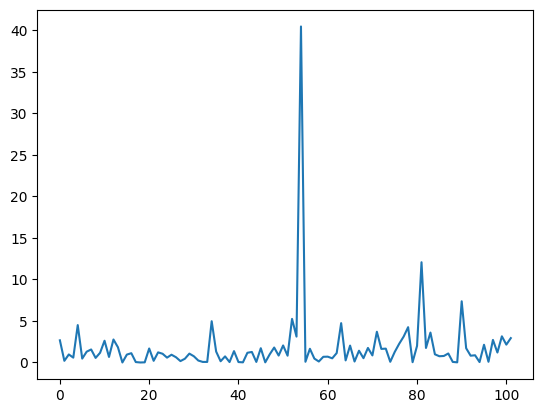

In [25]:
plt.plot(df_taipower['Outage_Duration_Hours'])

In [26]:
len(df_taipower[df_taipower['Outage_Duration_Hours']>3])

13